### Calling a subgraph inside a node
- Workflow
- Main Graph: START -> Generate -> Translate (Invoke the subgraph inside it) -> END
- Sub grpah: START -> Translate -> END

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [ ]:
# Creating saubgraph.
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [4]:
subgraph_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.7
)

In [5]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [6]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [7]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [14]:
parent_llm = ChatGroq(
     model="openai/gpt-oss-120b",
    temperature=0.7
)

In [15]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [16]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [11]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

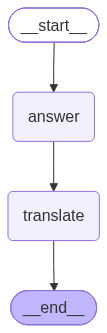

In [17]:
graph = parent_builder.compile()

graph

In [18]:
graph.invoke({'question': 'What is quantum physics in 20 words'})

{'question': 'What is quantum physics in 20 words',
 'answer_eng': 'Quantum physics studies microscopic particles, describing their probabilistic behavior, wave‑particle duality, quantized energy, and entanglement through frameworks like Schrödinger equation.',
 'answer_hin': 'क्वांटम भौतिकी सूक्ष्म कणों का अध्ययन करती है, उनके संभाव्य व्यवहार, तरंग‑कण द्वैत, क्वांटाइज़्ड ऊर्जा और उलझन को श्रोडिंगर समीकरण जैसी रूपरेखाओं के माध्यम से वर्णित करती है।'}

### Adding a subgraph as a node
- Only one state will be created for both unlike subgraph inside a node which has 2 states
- In this we need to to invoke the subgraph like we did it in subgraph inside a node. We will add this as a node.

In [19]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [20]:
load_dotenv()

True

In [21]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [22]:
parent_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.7
)

subgraph_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.7
)

In [23]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [24]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [25]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}


In [26]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

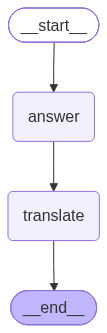

In [27]:
graph = parent_builder.compile()

graph

In [29]:
graph.invoke({'question': 'Explain Quantum Computer in 20 words'})

{'question': 'Explain Quantum Computer in 20 words',
 'answer_eng': 'Quantum computer uses qubits, superposition, entanglement to process many states simultaneously, solving certain problems faster than classical computers for optimization.',
 'answer_hin': 'क्वांटम कंप्यूटर क्यूबिट, सुपरपोज़िशन और एंटैंगलमेंट का उपयोग करके कई स्थितियों को एक साथ प्रोसेस करता है, जिससे अनुकूलन जैसे कुछ समस्याओं को क्लासिकल कंप्यूटरों की तुलना में तेज़ी से हल किया जा सकता है।'}